# Assignment 5: Data Visualization
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Visualization**, the third/fourth stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.

In this notebook, you will be working with two datasets: the Peter/Paul Northern Lakes Chemistry & Nutrients processed dataset, and the NEON Niwot Litter Mass Trap dataset. Specifically, we will be visualizing various aspects and relationships among the variable in these datasets. 

As always, address the tasks below to the best of your ability. Be sure to ask if any question is ambigious or unclear. When complete. Export your notebook into an HTML formatted document. Also, stage, commit, and push your assignment to your GitHub repository. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1.2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [2]:
# 1.1 Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import calendar

In [3]:
# 1.2 Paths 
project_fldr = Path.cwd().parent
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'Processed_Key'

print(project_fldr)
print(raw_fldr)
print(processed_fldr)

/Users/masonbunker/Desktop/Duke/Environmental Data Exploration/ENVR700
/Users/masonbunker/Desktop/Duke/Environmental Data Exploration/ENVR700/data/raw
/Users/masonbunker/Desktop/Duke/Environmental Data Exploration/ENVR700/data/Processed_Key


#### 2. Ingest Data & Wrangle
* 2.1 NTL LTER data for Peter and Paul Lakes
    - Read the `'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv'` file into a dataframe. 
    - Convert the `sampledate` column to a datetime object.
    - Create a `month_abb` column to be an ordered categorical data type with levels for all months.
    - Display the first 5 records of the dataframe
* 2.2 NEON NIWO Litter Mass Trap Data (processed)
    - Read in the `NEON_NIWO_Litter_mass_trap_Processed.csv` file into a dataframe.
    - Convert the `collectDate` column to a datatime object.
    - Create a `year` column from the `collectDate` column 
    - Display the first 5 records of the dataframe

In [6]:
# 2.1.1 Import the NTL_LTER dataset as a dataframe, converting the sampledate field to a datetime object

PeterPaul_NTL_LTER = pd.read_csv(
    processed_fldr/'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
    parse_dates=['sampledate']
)

PeterPaul_NTL_LTER.head(5)

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN


In [14]:
# 2.1.2 Create a month column to be an ordered categorical data type with levels for all months.
PeterPaul_NTL_LTER["month_abb"] = pd.Categorical(
    values=PeterPaul_NTL_LTER["sampledate"].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:],
)

PeterPaul_NTL_LTER.dtypes

lakename                      str
year4                       int64
daynum                      int64
month                       int64
sampledate         datetime64[us]
depth                     float64
temperature_C             float64
dissolvedOxygen           float64
irradianceWater           float64
irradianceDeck            float64
tn_ug                     float64
tp_ug                     float64
nh34                      float64
no23                      float64
po4                       float64
month_abb                category
dtype: object

In [9]:
# 2.1.3 Display the first 5 records of the dataframe

PeterPaul_NTL_LTER.head(5)

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,month_abb
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN,May


In [15]:
# 2.2.1 Import the NEON NIWO dataset, setting the `collectDate` field to a datetime object

NEON_NIWO = pd.read_csv(
    processed_fldr/"NEON_NIWO_Litter_mass_trap_Processed.csv",
    parse_dates=["collectDate"]
)

NEON_NIWO.head()

,plotID,trapID,collectDate,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84


In [17]:
# 2.2.2 Create a year column from the `collectDate` field.

NEON_NIWO = NEON_NIWO.assign(year = lambda df: df["collectDate"].dt.year)

In [18]:
# 2.2.3 Display the first 5 records of the dataframe

NEON_NIWO.head(5)

,plotID,trapID,collectDate,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum,year
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84,2016
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84,2016
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84,2016


#### 3. Set your Seaborn Theme
* Choose a Seaborn theme; set its context to what you feel is appropriate for this notebook
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set the theme's runtime configuration (`rc`) so that plots have a *title size* of 20 and use a serif *font family*.

In [24]:
#3. Set the seaborn theme

sns.set_theme(
    style="white",
    context="notebook",
    palette="colorblind",
    font_scale=.8,
    rc={
        "font.family": "serif",
        "axes.titlesize": 20
    }
)


#### 4. Relationship of Total Phosphorous to Phosphate
Total Phosphorus (TP) measures every form of phosphorus in a lake, while phosphate (orthophosphate or PO₄) is the specific, dissolved, inorganic fraction that algae can directly absorb. We might therefore expect PO₄ to increase with increases in TP; we want to confirm that expectation with a visualization of our data. 
- Create a scatterplot of PO₄ as a function of TP (assign TP to the x-axis), using separate aesthetics to differientiate the two (Peter and Paul) lakes.
- Adjust your axes to hide extreme values. (Hint: change the limits using `xlim()` and `ylim()`).
- If your plot as many overlapping points, consider making the point features semi-transparent.
- Ensure your plot has an appropriate title, axis labels, and other stylistic features to make it look tidy and professional. 

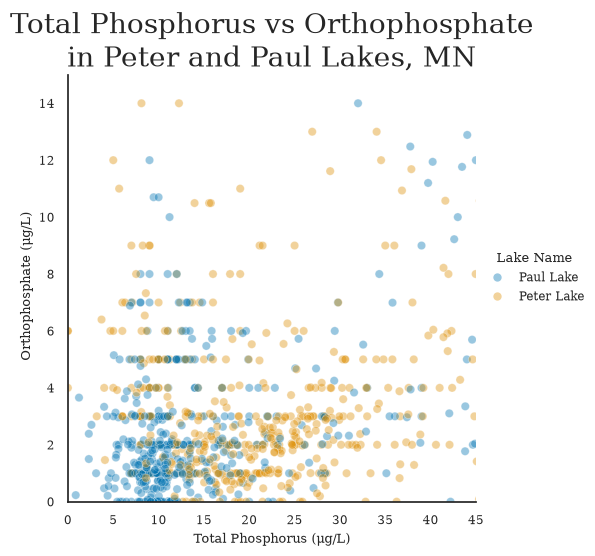

In [96]:
# 4. Create a scatterplot of PO4 vs TP

PO4vsTP = sns.relplot(
    data=PeterPaul_NTL_LTER,
    x = "tp_ug",
    y = "po4",
    hue = "lakename",
    alpha = .4
)

PO4vsTP.set(
    xlim=(0,45),
    ylim= (0,15),
    title= "Total Phosphorus vs Orthophosphate" \
    "\nin Peter and Paul Lakes, MN",
    xlabel= "Total Phosphorus (\N{Greek small letter mu}g/L)",
    ylabel= " Orthophosphate (\u03BCg/L)"
)

sns.move_legend(
    PO4vsTP, 
    loc= "right",
    title='Lake Name',
    facecolor="#FFFEFE",
)

#### 4-Challenge
* Re-construct your plot so that it includes a regression line (hint: `lmplot()`)
* Note that for the regression line to exclude extreme values, you'll have to filter the dataframe used in the plot; setting the x and y limits won't do that for you. 

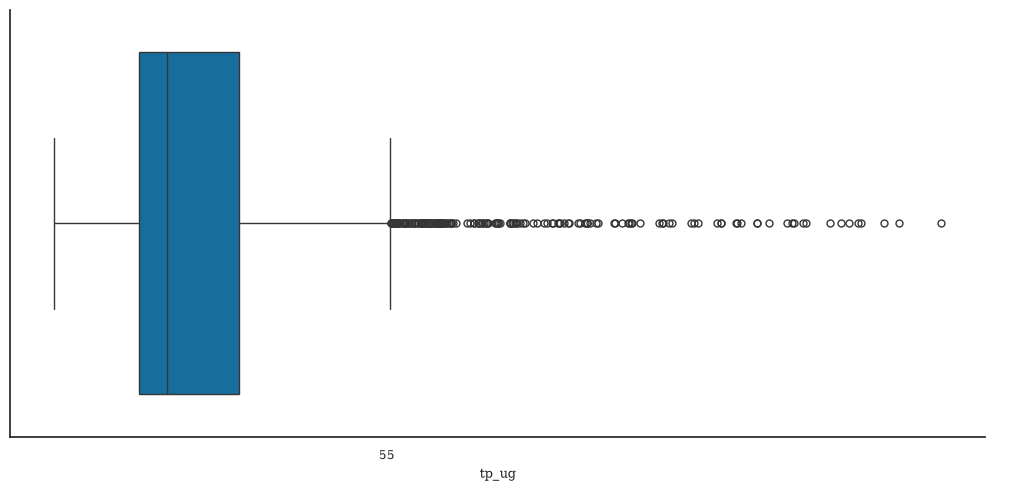

In [120]:
# looking at the actual extents and outliersfor the data

sns.catplot(
    data=PeterPaul_NTL_LTER,
    x='tp_ug',
    #x = "po4",
    #hue='lakename',
    #log_scale = True,
    aspect=2,
    #height=9,
    kind='box',
    #kind='violin',
).set(xticks=[55])

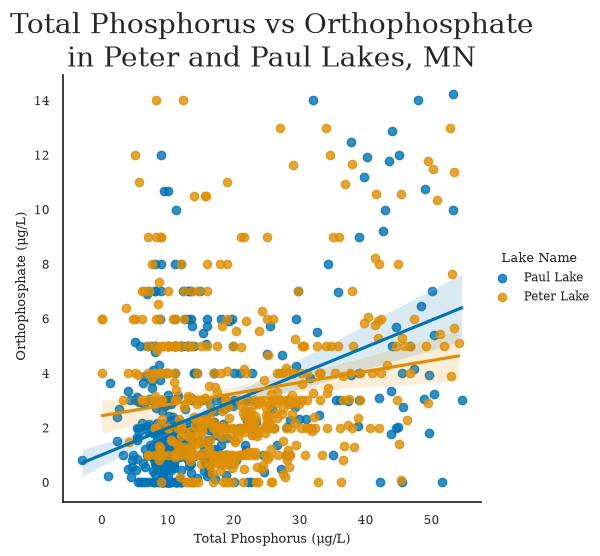

In [125]:
# 4-challenge

# used above code block to check the outliers for the two

PO4vsTP_reg =sns.lmplot(
    data= (
        PeterPaul_NTL_LTER
        .loc[lambda df: df["po4"] < 15]
        .loc[lambda df: df["tp_ug"] < 55 ]
    ),
    x = "tp_ug",
    y = "po4",
    hue = "lakename",
)

PO4vsTP_reg.set(
    title= "Total Phosphorus vs Orthophosphate" \
    "\nin Peter and Paul Lakes, MN",
    xlabel= "Total Phosphorus (\N{Greek small letter mu}g/L)",
    ylabel= " Orthophosphate (\u03BCg/L)"
)

sns.move_legend(
    PO4vsTP_reg, 
    loc= "right",
    title='Lake Name',
    facecolor="#FFFEFE",
)

### 5. Comparison of monthly trends of select variables across lakes
We are interested in comparing monthly trends in three lake variables: Total Nitrogren, Total Phosphorus, and Temperature, contrasting differences among the two lakes.
* 5.1 First, you'll need to "melt" your data so that all temperature, TP, and TN measures appear in a single column alongside a separate column that lists whether the row is temperature, TN, or TP record.
* 5.2 Construct a box plot of the 3 lake measurements such that
    - Months appear along the x-axis
    - Peter and Paul lake data are shown in different colors
    - The plots for temperature, TN, and TP are shown as separate facets, stacked vertically, and each have their own y-axis scale (hint: `sharey=False`).
    - Remove the individual plot titles and x-axis labels (hint: set to an empty string `""`).
    - Set the y-axis labels to indicate the plots of Temperature, Total Nitrogen, and Total Phosphorus. 

In [136]:
# 5.1 Melt the NTL LTR dataset so that Temperature, TN, and TP measures are consolidated in a single column

PeterPaul_Long = PeterPaul_NTL_LTER.melt(
    id_vars= ["lakename", "month_abb"],
    value_vars=["tn_ug", "tp_ug", "temperature_C"],
    value_name= "measurement",
    var_name="measurement type"
)

## I would like to remove the NA values but I don't believe it is nevessary

PeterPaul_Long.sample(10)


,lakename,month_abb,measurement type,measurement
44597,Peter Lake,Aug,tp_ug,NaN
51689,Peter Lake,Jul,temperature_C,24.6
42621,Paul Lake,Aug,tp_ug,NaN
65278,Peter Lake,Jun,temperature_C,18.5
64122,Paul Lake,Jul,temperature_C,7.9
60415,Peter Lake,May,temperature_C,6.7
13104,Peter Lake,Jul,tn_ug,NaN
49869,Paul Lake,Sep,temperature_C,8.7
51029,Peter Lake,Jul,temperature_C,14.2
63419,Paul Lake,Jun,temperature_C,18.7


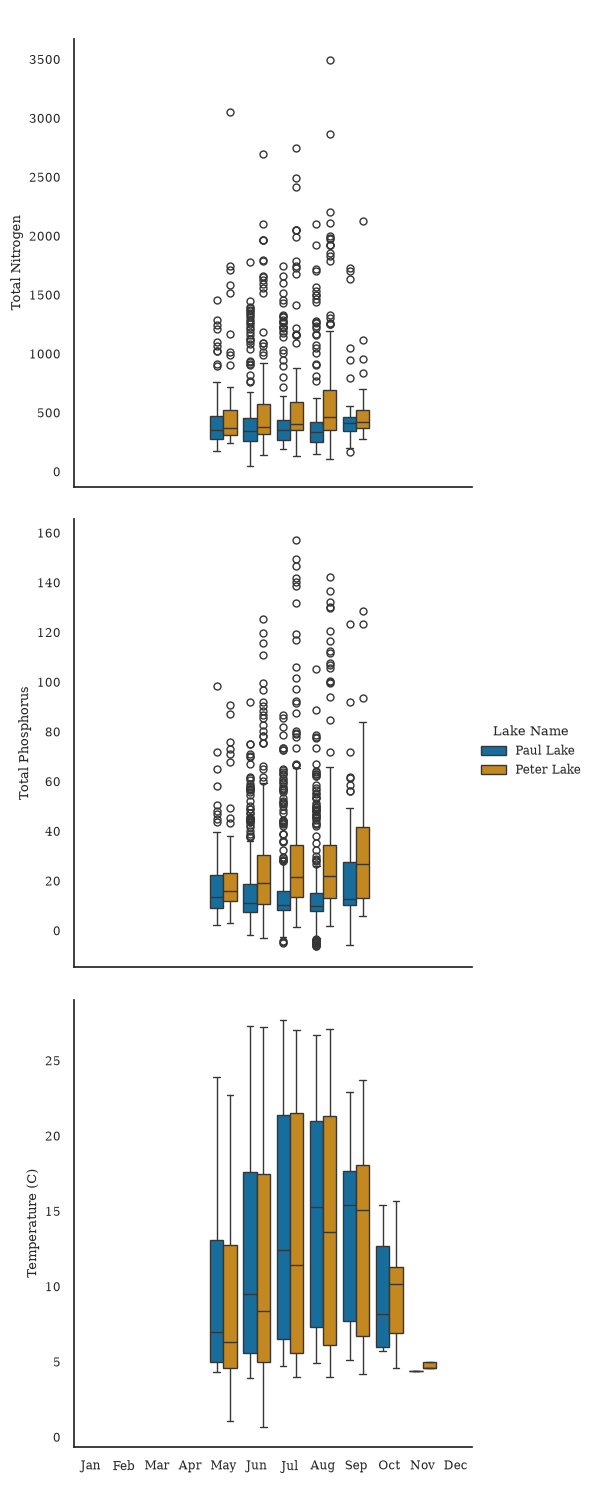

In [161]:
# 5.2 Create the faceted plot

g = sns.catplot(
    data=PeterPaul_Long,
    x="month_abb",
    y="measurement",
    kind="box",
    col="measurement type",
    col_wrap=1,
    hue="lakename",
    sharey=False #make the facets NOT have the same scale
)

# 5.3 Style the plot

g.set(
    xlabel= " ",
    title= " ",
)

g.axes[0].set_ylabel("Total Nitrogen")
g.axes[1].set_ylabel("Total Phosphorus")
g.axes[2].set_ylabel("Temperature (C)")

# 5.4 Set the legend

sns.move_legend(
    g, 
    loc= "right",
    title='Lake Name',
    facecolor="#FFFEFE",
)

#### ✅ Question
**What do you observe about the variables of interest over seasons and between lakes?**
> **Answer**:  Data is not present over the winter for all three variables, though temperature has data for May-Nov, whereas P & N have data from May-Sep. Between lakes, Peter has a lower temperature but more nutirents and vice versa. This suggests an inverse relationship between temperature and nutrient load.
>  

### 6. Dry mass of needles over time
We are curious how the amount of needles is changing from year to year, specifically how those trends might appear across different land cover types. To do that we'll explore a few visualizations. 

#### 6.1 Change in needle dry mass over time, single plot
* Plot a subset of the litter dataset by displaying only the "Needles" functional group in a single plot figure. 
* Plot the dry mass of needle litter by year, separating by NLCD class with a color aesthetic. (no need to adjust the name of each land use)
* Treat the years as categorical data in your selection of `displot()`, `catplot()`, or `relplot()` plotting functions. 
* Select a plotting function subplot type (e.g. "scatterplot" for relplot, "swarmplot" for catplot) that you feel best illustrates change over time of the needle dry mass from year to year to year for the different land cover types.
* Style your plot for professionalism and clarity.  Specifically:
    - Give your plot a title.
    - Label axes appropriately. ("Year" is an optional label, as it can be considered obvious.)
    - Title and place your legend to maximize clarity.
    - Ensure that your font sizes are appropriate. (Hint: adjust plot height and aspect.)
    - *You can use default cover type names, e.g. `shrubScrub`.*

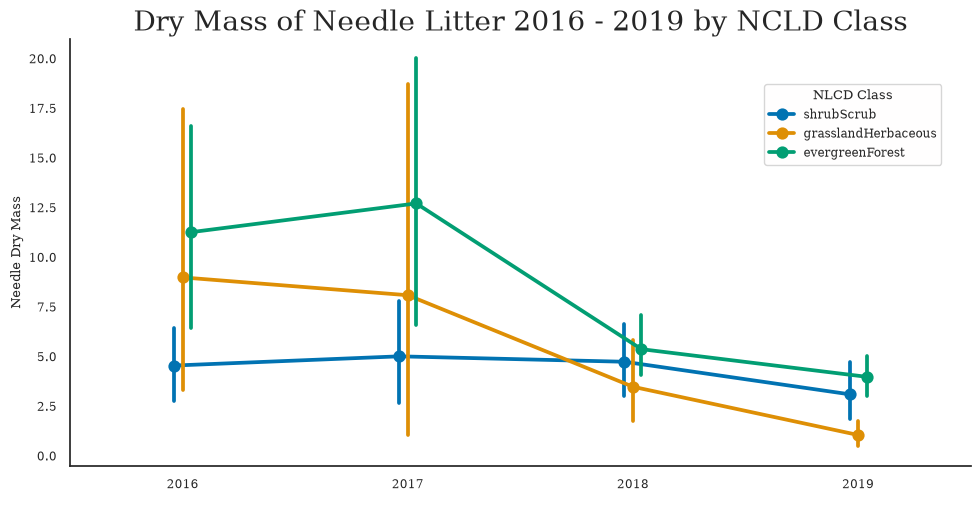

In [ ]:
# 6. Plot the dry mass of needles over time, separated by NLCD cover type

#subset the data
Needles = NEON_NIWO.loc[lambda df: df["functionalGroup"]=="Needles"]

Needles["year"] = Needles["year"].astype("category")

NeedlesMass = sns.catplot(
    data = Needles,
    y= "dryMass",
    x = "year",
    hue="nlcdClass",
    kind="point",
    aspect=2,
    height=5,
    dodge=True #this makes the error bars not overlap!!
)

# I almost went with boxen as my plot type but it felt too chaotic, for seeing the change across the three I think this is much clearer, 
# especially with all three on the same plot

NeedlesMass.set(
    xlabel=" ",
    ylabel= "Needle Dry Mass",
    title="Dry Mass of Needle Litter 2016 - 2019 by NCLD Class"
)

sns.move_legend(
    NeedlesMass, 
    loc='right',
    title='NLCD Class',
    facecolor="#FFFEFE",
    #shadow=True,
    bbox_to_anchor=(0.82,0.8),
    #title_fontsize=12,
    #fontsize=10,
    ncols=1,
    frameon=True
)


#### 6.2 Change in needle dry mass over time, facet plot
* Recreate your plot above, but instead of a single plot, break your plot into 3 facets: one for each cover type. 
* You are welcome to explore different plot subtypes than the previous plot. 
* Decide whether you want to stack the facet plots vertically or horizontally based on how well it communicates differences in the trends and magnitude of leaf litter change over time across the different cover types. 
* As before, style your plot for professionalism and clarity. 

Text(0.5, 1.0, 'Evergreen Forest Yearly Needle Dry Mass')

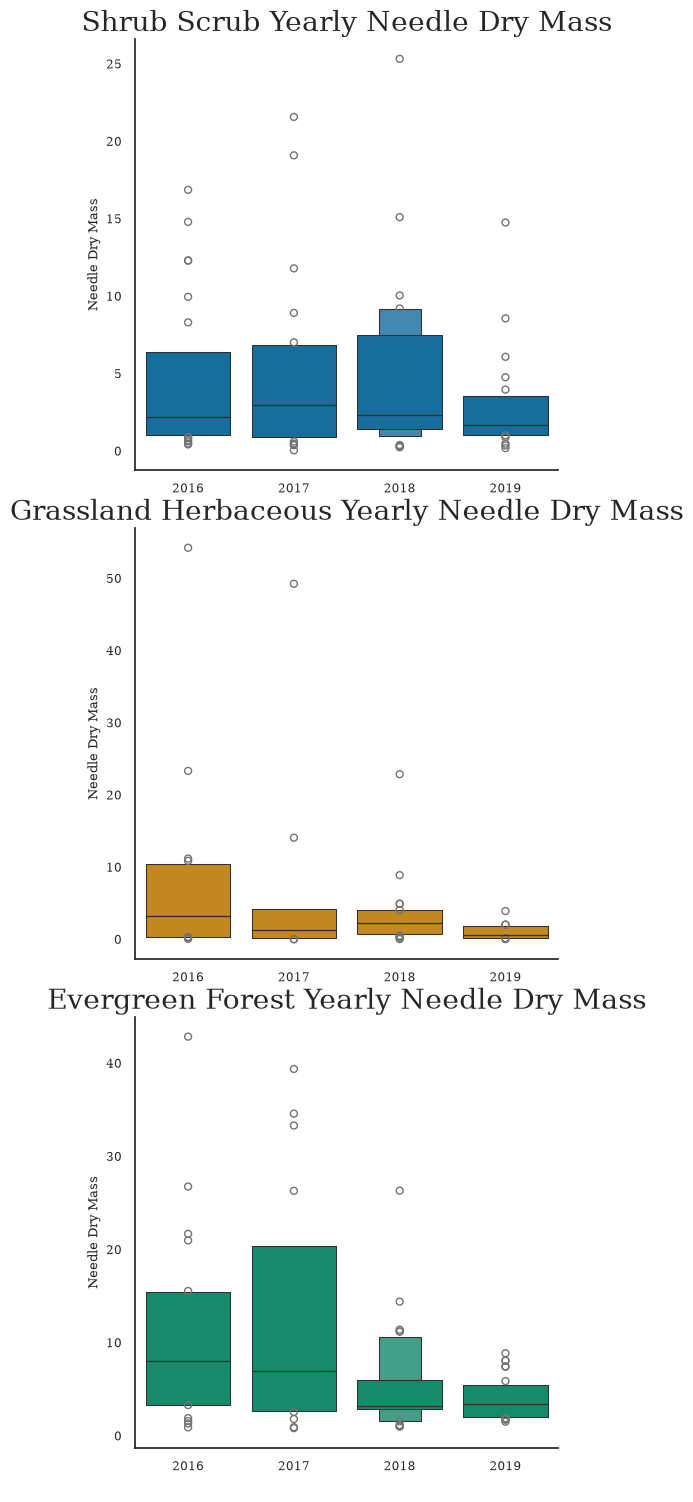

In [354]:
# 6.2 Plot the dry mass of needles over time, faceted by NLCD cover type

NeedlesMassFacet = sns.catplot(
    data = Needles,
    y= "dryMass",
    x = "year",
    hue="nlcdClass",
    col ="nlcdClass",
    col_wrap=1,
    kind="boxen",
    sharey=False,
    sharex=False,
    legend=False
)

NeedlesMassFacet.set(
    xlabel=" ",
    ylabel= "Needle Dry Mass",
)

NeedlesMassFacet.axes[0].set_title("Shrub Scrub Yearly Needle Dry Mass", loc="center")
NeedlesMassFacet.axes[1].set_title("Grassland Herbaceous Yearly Needle Dry Mass", loc="center")
NeedlesMassFacet.axes[2].set_title("Evergreen Forest Yearly Needle Dry Mass", loc="center")


#### ✅ Question
**Which of the two plots do you feel better reveals the pattern of needle dry mass over time? Why?**
> **Answer**:  I think the first plot is easier to interpret and shows the clearer pattern change of decrease across the years for grassland herbaceous and evergreen forest. This version still shows the spread of data with the error bars and communicates the variability within a year.
>  


#### ✅ Question
**Explain your choice of subplot in the plots above. What aspects of that subplot type led to your choice.**
> **Answer**:  I chose the boxen method for the subplots in part because this was my initial instinct with 6.1 but I found it too cluttered when all three cover classes were displayed simultaneously. I think this version is a helpful complement to that of 6.1 because it shows the spread of the data, especailly the outliers, in a neat way. The varying widths of the boxes also help establish the data concentrations in a way that I find more legible than that of a violin plot. Primarily, I wanted a complimentary data visualization that showed more specifics of the spread of the data.
>  